In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("Threats (1).csv")
data = data.drop(columns = ["Unnamed: 0","id"])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135341 entries, 0 to 135340
Data columns (total 44 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   dur                135341 non-null  float64
 1   proto              135341 non-null  object 
 2   service            135341 non-null  object 
 3   state              135341 non-null  object 
 4   spkts              135341 non-null  int64  
 5   dpkts              135341 non-null  int64  
 6   sbytes             135341 non-null  int64  
 7   dbytes             135341 non-null  int64  
 8   rate               135341 non-null  float64
 9   sttl               135341 non-null  int64  
 10  dttl               135341 non-null  int64  
 11  sload              135341 non-null  float64
 12  dload              135341 non-null  float64
 13  sloss              135341 non-null  int64  
 14  dloss              135341 non-null  int64  
 15  sinpkt             135341 non-null  float64
 16  di

## label encoding for proto service , state and attack_cat

In [5]:
def label_encoding(name):
    uni = data[f"{name}"].unique()
    l = [i for i in range(len(uni))]
    dic = dict(zip(uni,l))
    data[f"{name}"] = data[f"{name}"].map(dic)
    
label_encoding("proto")
label_encoding("service")
label_encoding("state")
label_encoding("attack_cat")
data = data.astype(float)

In [6]:
target = data["attack_cat"]
data = data.drop(columns = ["attack_cat"])

In [7]:
corr = data.corr()

In [8]:
def correlation_check(i,j):
    return data[[i, j]].corr().iloc[0, 1]

## dropping features having correlation more than .7

In [9]:
columns = list(data.columns)
for i in columns:
    for j in columns:
        cor_value = correlation_check(i,j)
        if cor_value == 1:
            continue
                
        elif abs(cor_value) >= .7:
            if j in columns:
                data = data.drop(columns = [j])
                columns.remove(j)
                print(f"Correlation between {i} and {j}: {cor_value}")
                print(f"droppped {j}")
            else:
                continue     
        else:
            continue

Correlation between state and dttl: -0.9777773114676039
droppped dttl
Correlation between state and swin: -0.9564073287283896
droppped swin
Correlation between state and dtcpb: -0.7945256528107824
droppped dtcpb
Correlation between state and tcprtt: -0.7536997089349701
droppped tcprtt
Correlation between state and ackdat: -0.7294430000959966
droppped ackdat
Correlation between state and ct_state_ttl: 0.786502590153585
droppped ct_state_ttl
Correlation between spkts and sbytes: 0.991083640311391
droppped sbytes
Correlation between spkts and sloss: 0.9912988088546151
droppped sloss
Correlation between dpkts and dbytes: 0.9730097083383443
droppped dbytes
Correlation between dpkts and dloss: 0.9731621314901971
droppped dloss
Correlation between sinpkt and is_sm_ips_ports: 0.9452100690517068
droppped is_sm_ips_ports
Correlation between dinpkt and sjit: 0.9230107916750923
droppped sjit
Correlation between stcpb and state: -0.7917547088699323
droppped state
Correlation between stcpb and dwin:

In [10]:
data = data.drop(columns = ["ct_ftp_cmd"])

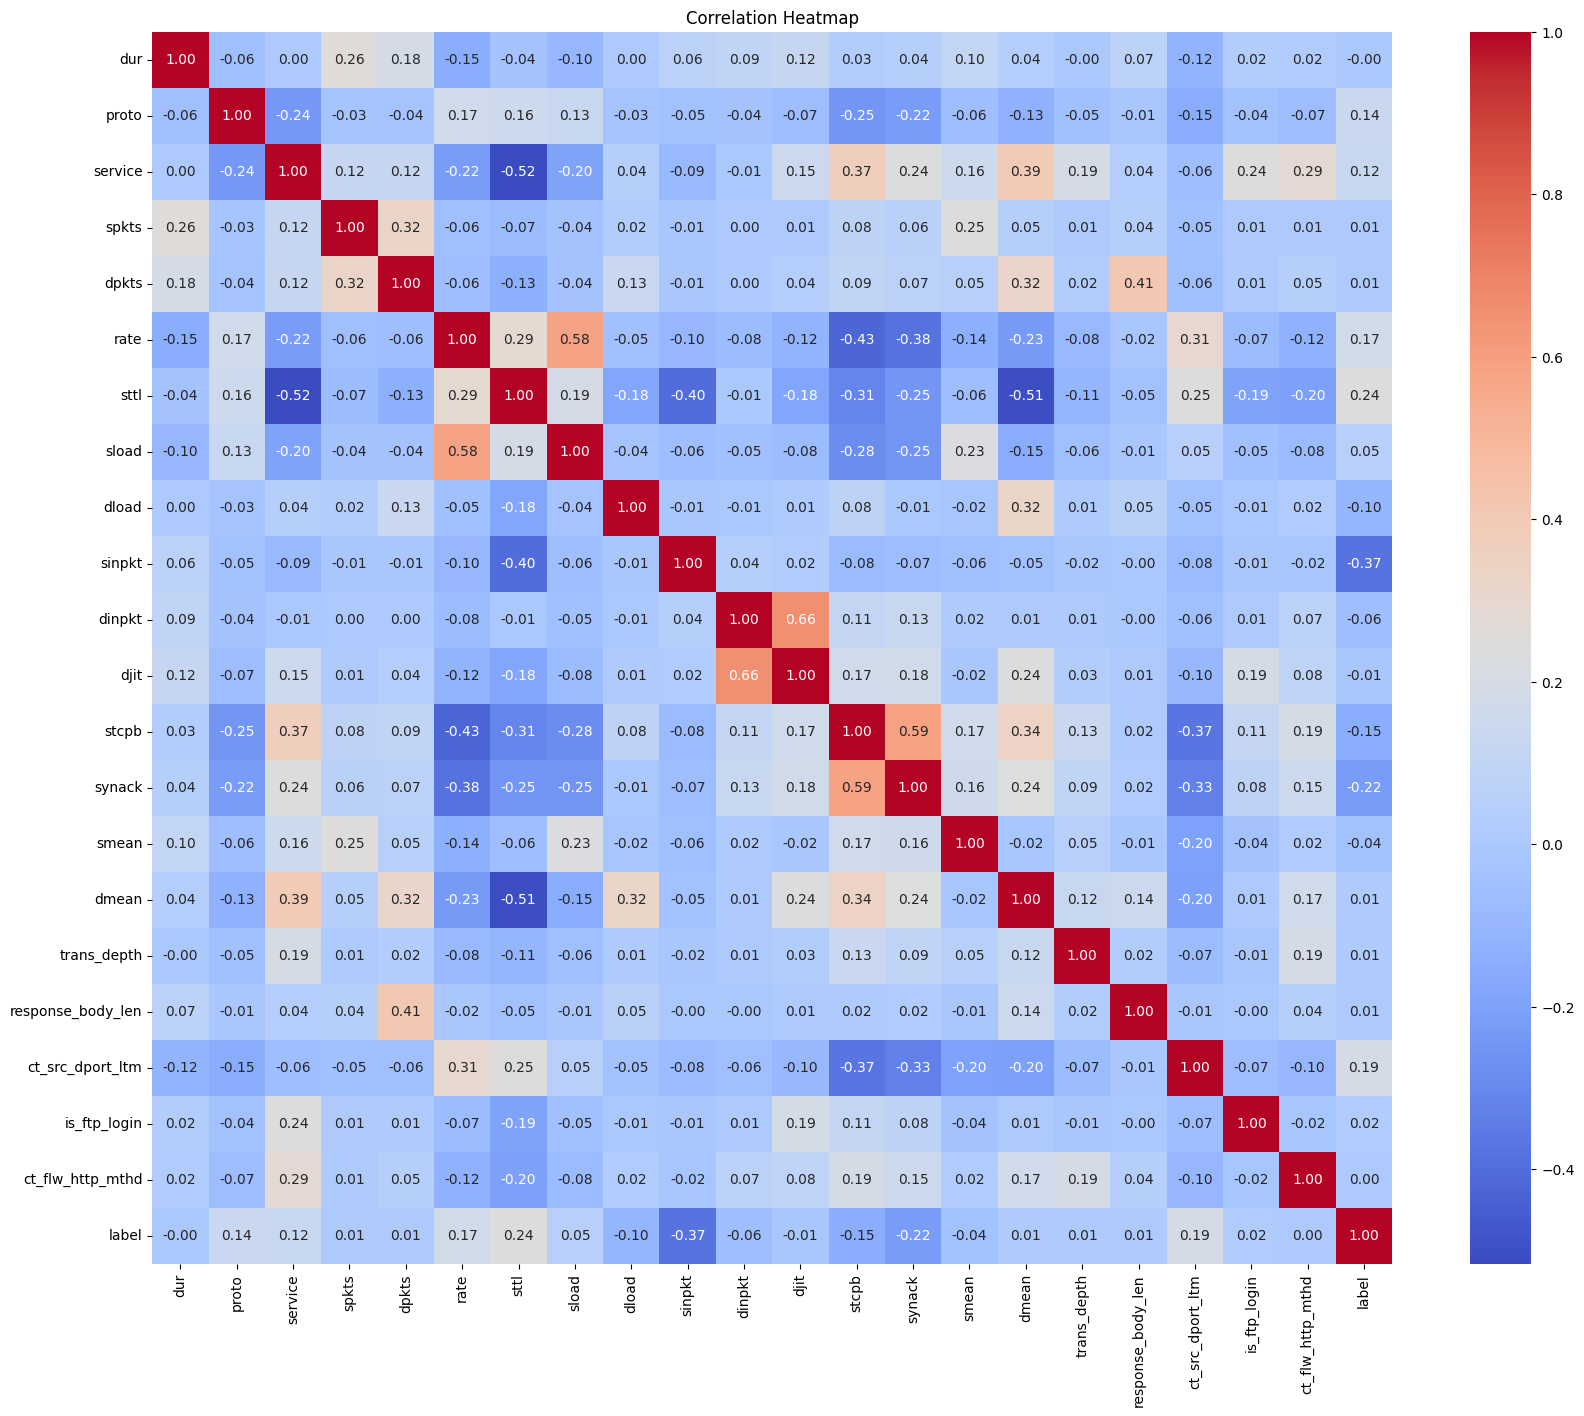

In [11]:
corr = data.corr()
plt.figure(figsize = (20,16))
sns.heatmap(corr, cmap = "coolwarm", annot= True, fmt = ".2f")
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap")
plt.show()

## splitting test train data using sklearn train_test_split

In [26]:
data
target = (pd.DataFrame(target)).values.reshape(-1,1)
target
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(data, target, test_size=.3, random_state=42)

In [ ]:
# def entropy_calc(x):
#     print(x.shape)
#     print(x)
#     x = x.iloc[:,0]
#     uniq = list(x.unique())
#     r= x.shape[0]
#     dic = dict(x.value_counts())
#     entropy = 0
#     for i in uniq:
#         p = float(dic[i]) / r
#         entropy -= ((p)*(np.log2(p)))
#     return entropy

# def info_gain(left_child,right_child,parent):
#     len_left = len(left_child)
#     len_right = len(right_child)
#     w_left = len_left/ (len_left+len_right)
#     w_right = len_right/ (len_left+len_right)
#     return (entropy_calc(parent) - (w_left*entropy_calc(left_child)) - (w_right*entropy_calc(right_child)))

# def split(x):
#     uni = []
#     for i in x.columns:
#         uni.append(x[i].unique())
    
#     best_split = {
#         "feature_index": None,
#         "threshold": None,
#         "information_gain": -float("inf")
#     }
    
#     feature_index = 0
#     for features in uni:
#         feature_data = x.iloc[:, feature_index]
#         feature_index += 1
#         for threshold in features:
#             left_child = []
#             right_child = []
            
#             # Iterate over feature values and split based on the threshold
#             for index, value in feature_data.items():
#                 if value < threshold:
#                     left_child.append((index, value))
#                 else:
#                     right_child.append((index, value))
            

#             left_child = pd.DataFrame(left_child).astype(float)
#             right_child = pd.DataFrame(right_child).astype(float)
#             feature_data = pd.DataFrame(feature_data).astype(float)

#             ig = info_gain(left_child, right_child, feature_data)
            
#             # Update the best split
#             if ig > best_split["information_gain"]:
#                 best_split["feature_index"] = feature_index - 1
#                 best_split["threshold"] = threshold
#                 best_split["information_gain"] = ig
    
#     return best_split


In [45]:
def entropy(x):
    uniq = np.unique(x)
    entropy = 0
    for i in uniq:
        p = len(x[x==i])/len(x)
        entropy -= p*(np.log2(p))
    return entropy
    
def information_gain(parent, l_child, r_child):
        weight_l = len(l_child) / len(parent)
        weight_r = len(r_child) / len(parent)
        gain = entropy(parent) - (weight_l*(entropy(l_child)) + weight_r*(entropy(r_child)))
        return gain

def split(data,feature_index,threshold):
    dataset_left = np.array([row for row in data if row[feature_index]<=threshold])
    dataset_right = np.array([row for row in data if row[feature_index]>threshold]) 
    return dataset_left, dataset_right

def compute_leaf_value(Y):
    Y = list(Y)
    return max(Y, key=Y.count)

def train_tree(X, Y, min_samples=2, max_depth=2):
    data = np.concatenate((X, Y), axis=1)
    return build_tree(data, 0, min_samples, max_depth)

def best_split_data(data, num_samples, num_features):
    best_split = {}
    max_info_gain = -float("inf")
    for feature_index in range(num_features):
        feature_values = data[:, feature_index]
        possible_thresholds = np.unique(feature_values)
        for threshold in possible_thresholds:
            dataset_left, dataset_right = split(data, feature_index, threshold)
            if len(dataset_left)>0 and len(dataset_right)>0:
                y, left_y, right_y = data[:, -1], dataset_left[:, -1], dataset_right[:, -1]
                curr_info_gain = information_gain(y, left_y, right_y)
                if curr_info_gain>max_info_gain:
                    best_split["feature_index"] = feature_index
                    best_split["threshold"] = threshold
                    best_split["dataset_left"] = dataset_left
                    best_split["dataset_right"] = dataset_right
                    best_split["info_gain"] = curr_info_gain
                    max_info_gain = curr_info_gain
    return best_split


def build_tree(data, curr_depth, min_samples_split, max_depth):
    X, Y = data[:, :-1], data[:, -1]
    num_samples, num_features = np.shape(X)

    if num_samples >= min_samples_split and curr_depth <= max_depth:
        best_split_dic = best_split_data(data, num_samples, num_features)
        
        if best_split_dic["info_gain"] > 0:
            left_subtree = build_tree(best_split_dic["dataset_left"], curr_depth + 1, min_samples_split, max_depth)
            right_subtree = build_tree(best_split_dic["dataset_right"], curr_depth + 1, min_samples_split, max_depth)
            return {
                "feature_index": best_split_dic["feature_index"],
                "threshold": best_split_dic["threshold"],
                "left": left_subtree,
                "right": right_subtree,
                "info_gain": best_split_dic["info_gain"]
            }
    leaf_value = compute_leaf_value(Y)
    return {"value": leaf_value}
    
def predict_data(X, tree):
    return [single_prediction(x, tree) for x in X]

def single_prediction(instance, tree):
    if "value" in tree:
        return tree["value"]

    feature_value = instance[tree["feature"]]
    if feature_value <= tree["threshold"]:
        return single_prediction(instance, tree["left"])
    else:
        return single_prediction(instance, tree["right"])

In [ ]:
tree_model = train_tree(X_train, Y_train.reshape(-1, 1), min_samples=2, max_depth=3)